# 📊 **Exploratory Data Analysis — BTC Price × Media**

### 🎯 **Objective**
Assess whether **media activity and tone** add useful signal on top of BTC market features for crash prediction.

### ⚠️ **Target Definition**
A crash is defined as a price drop of more than **10% within the next 7 days** — the same definition as in notebook 01 (BTC EDA).

- `1` → Crash
- `0` → No crash

### 🔬 **EDA Focus**
1. Check dataset alignment between price and media data
2. Merge both sources at the daily level
3. Measure linear, monotonic, and non-linear dependencies with the target
4. Select media features using a combined score (Spearman + MI)
5. Build a compact feature set for benchmarking

### 🚀 **Goal**
Determine whether **media-derived variables** bring complementary information beyond market momentum, volatility, and drawdown — and if so, which ones.


In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from pipelines.ml_benchmark import run_benchmark_pipeline

In [103]:
df_btc_price = pd.read_csv("../../data/gold/market/btc_usdt_1d_features.csv")
df_btc_media = pd.read_csv("../../data/gold/bitcoin_tone_gold.csv")

### 1. Initial Data Overview


In [104]:
df_btc_media.head()

,date,avg_tone,article_count,tone_ma_7,tone_ma_30,tone_lag_1,tone_lag_7,article_count_ma_3,article_count_lag_1
0,2609-03-05,-0.481394,1552,-0.537987,-0.619152,-0.533521,-0.375572,3007.666667,4451
1,2609-03-06,-0.021060,2007,-0.533938,-0.600656,-0.481394,-0.049405,2670.000000,1552
2,2609-03-07,-1.067670,5574,-0.644736,-0.608371,-0.021060,-0.292084,3044.333333,2007
3,2609-03-08,-0.494609,5580,-0.652728,-0.630323,-1.067670,-0.438668,4387.000000,5574
4,2609-03-09,-1.259748,5469,-0.670066,-0.682481,-0.494609,-1.138378,5541.000000,5580


In [105]:
print(f"{df_btc_price.shape[0]} rows and {df_btc_price.shape[1]} columns in the price dataset.")
print(f"{df_btc_media.shape[0]} rows and {df_btc_media.shape[1]} columns in the media dataset.")


3115 rows and 30 columns in the price dataset.
129 rows and 9 columns in the media dataset.


**Observation:**
The media source (`bitcoin_tone_gold.csv`) is a **bitcoin-specific gold file** (129 rows, 9 columns). No coin filtering is required — all rows are already Bitcoin media data with pre-engineered features.

**Impact:**
The merge window is fully determined by the media file's date range. The BTC price dataset is much larger (3 115 rows), so the inner join will restrict the training window to the ~3-year media coverage period.


In [106]:
df_btc_price[df_btc_price["open_time"] == df_btc_price["open_time"].min()]

,open_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,...,lag_volume_norm,lag_buy_pressure,momentum_acc,volatility_ratio,momentum_volatility,pressure_x_return,ma_7,ma_30,ma_ratio,target
0,2017-09-16,3674.01,3950.0,3470.66,3714.95,1297.563953,4.804878e+06,8809,624.887842,2.314536e+06,...,2.390714,0.4907,-0.156191,1.727747,-0.013297,0.001946,3864.46,4239.663667,0.911502,1


### 2. Time Alignment and Daily Aggregation

The media source is a **bitcoin-specific gold file** (`bitcoin_tone_gold.csv`) with **9 pre-engineered columns**: `avg_tone`, `article_count`, and derived features (`tone_ma_7`, `tone_ma_30`, `tone_lag_1`, `tone_lag_7`, `article_count_ma_3`, `article_count_lag_1`).

The dates in this file are stored with an incorrect year offset (e.g. year 2609 instead of the real year). The alignment cell below auto-detects the correct offset and corrects the dates before merging with the BTC price series via an **inner join** — only days present in both datasets are kept.


In [107]:
print(f"Media dataset: {df_btc_media.shape[0]} rows, {df_btc_media.shape[1]} columns")
print(f"Media columns: {list(df_btc_media.columns)}")
print(f"Media date range (raw): {df_btc_media['date'].min()} to {df_btc_media['date'].max()}")

Media dataset: 129 rows, 9 columns
Media columns: ['date', 'avg_tone', 'article_count', 'tone_ma_7', 'tone_ma_30', 'tone_lag_1', 'tone_lag_7', 'article_count_ma_3', 'article_count_lag_1']
Media date range (raw): 2609-03-05 to 2612-01-10


In [108]:
def convert_media_dates_with_best_offset(raw_dates, min_price_date, max_price_date):
    """
    Detect the year offset in media dates (e.g. year 2609 instead of 2018) and
    return corrected dates. Tries all offsets that would map the raw year into the
    BTC price window, then picks the one with the most overlapping dates.
    """
    sample = next((str(v).strip() for v in raw_dates if pd.notna(v)), None)
    if sample is None:
        return pd.Series([pd.NaT] * len(raw_dates)), 0, 0, 0

    try:
        raw_year = int(sample[:4])
    except ValueError:
        raw_year = 0

    price_min_year = min_price_date.year
    price_max_year = max_price_date.year
    candidates = list(range(raw_year - price_max_year - 1, raw_year - price_min_year + 2))
    candidates = [c for c in candidates if c > 0]
    if not candidates:
        candidates = [0]

    best_offset = None
    best_dates = None
    best_overlap = -1
    best_valid = -1

    for offset in candidates:
        parsed = []
        for value in raw_dates:
            if pd.isna(value):
                parsed.append(pd.NaT)
                continue
            s = str(value).strip()
            parts = s.split("-")
            if len(parts) != 3:
                parsed.append(pd.NaT)
                continue
            year_str, month, day = parts
            try:
                year = int(year_str) - offset
            except ValueError:
                parsed.append(pd.NaT)
                continue
            try:
                parsed.append(pd.Timestamp(f"{year:04d}-{month}-{day}"))
            except Exception:
                parsed.append(pd.NaT)

        parsed = pd.Series(parsed)
        valid = parsed.notna().sum()
        overlap = ((parsed >= min_price_date) & (parsed <= max_price_date)).sum()

        if overlap > best_overlap or (overlap == best_overlap and valid > best_valid):
            best_offset = offset
            best_dates = parsed
            best_overlap = overlap
            best_valid = valid

    return best_dates, best_offset, best_valid, best_overlap


df_btc_price["open_time"] = pd.to_datetime(df_btc_price["open_time"], errors="coerce")
min_price_date = df_btc_price["open_time"].min()
max_price_date = df_btc_price["open_time"].max()

df_btc_media["date"], chosen_offset, valid_dates, overlap_dates = convert_media_dates_with_best_offset(
    df_btc_media["date"],
    min_price_date,
    max_price_date,
)

print(f"Chosen year offset for media dates: {chosen_offset}")
print(f"Valid media dates after parsing: {valid_dates}")
print(f"Overlapping media dates with BTC price range: {overlap_dates}")
print(f"Invalid media dates after parsing: {df_btc_media['date'].isna().sum()}")

df_btc_media = (
    df_btc_media
    .dropna(subset=["date"])
    .sort_values("date")
    .drop_duplicates("date", keep="last")
    .reset_index(drop=True)
)

if df_btc_media.empty:
    raise ValueError("Media dataset is empty after date parsing.")

min_media_date = df_btc_media["date"].min()
max_media_date = df_btc_media["date"].max()

print(f"BTC price range:  {min_price_date.date()} to {max_price_date.date()}")
print(f"BTC media range:  {min_media_date.date()} to {max_media_date.date()}")

df_btc_media = df_btc_media[
    (df_btc_media["date"] >= min_price_date) &
    (df_btc_media["date"] <= max_price_date)
].copy()

print(f"After filtering to BTC price range: {df_btc_media.shape[0]} rows remain in the media dataset.")

if df_btc_media.empty:
    raise ValueError(
        f"No overlapping dates between BTC price ({min_price_date.date()} to {max_price_date.date()}) "
        f"and media ({min_media_date.date()} to {max_media_date.date()})."
    )

df_btc_media.head()


Chosen year offset for media dates: 586
Valid media dates after parsing: 129
Overlapping media dates with BTC price range: 129
Invalid media dates after parsing: 0
BTC price range:  2017-09-16 to 2026-03-27
BTC media range:  2023-03-05 to 2026-01-10
After filtering to BTC price range: 129 rows remain in the media dataset.


,date,avg_tone,article_count,tone_ma_7,tone_ma_30,tone_lag_1,tone_lag_7,article_count_ma_3,article_count_lag_1
0,2023-03-05,-0.481394,1552,-0.537987,-0.619152,-0.533521,-0.375572,3007.666667,4451
1,2023-03-06,-0.021060,2007,-0.533938,-0.600656,-0.481394,-0.049405,2670.000000,1552
2,2023-03-07,-1.067670,5574,-0.644736,-0.608371,-0.021060,-0.292084,3044.333333,2007
3,2023-03-08,-0.494609,5580,-0.652728,-0.630323,-1.067670,-0.438668,4387.000000,5574
4,2023-03-09,-1.259748,5469,-0.670066,-0.682481,-0.494609,-1.138378,5541.000000,5580


**Observation:**
The auto-detection algorithm found **year offset 586** (raw year 2609 → 2023), giving a valid media window of **2023-03-05 to 2026-01-10**. All 129 dates fall within the BTC price range with **zero invalid or missing dates**.

**Conclusion:**
The date alignment is clean. The effective modeling window covers approximately **3 years** (2023–2026), spanning the post-FTX recovery, the 2024 halving cycle, and BTC's run to new all-time highs — a well-defined and market-relevant period.


### 3. Merged BTC + Media Dataset


In [109]:
df_btc_media_and_price = pd.merge(df_btc_price, df_btc_media, left_on="open_time", right_on="date", how="inner")
print(f"Merged dataset: {df_btc_media_and_price.shape[0]} rows, {df_btc_media_and_price.shape[1]} columns")
df_btc_media_and_price.drop(columns=["open_time", "date"], inplace=True)
df_btc_media_and_price.head()

Merged dataset: 129 rows, 39 columns


,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,return_1d,...,ma_ratio,target,avg_tone,article_count,tone_ma_7,tone_ma_30,tone_lag_1,tone_lag_7,article_count_ma_3,article_count_lag_1
0,22346.57,22662.09,22189.22,22430.24,154841.75786,3.473011e+09,4835978,77394.35765,1.735989e+09,0.003744,...,0.990859,0,-0.481394,1552,-0.537987,-0.619152,-0.533521,-0.375572,3007.666667,4451
1,22430.24,22602.19,22258.00,22410.00,203751.82957,4.569102e+09,6471278,102110.26304,2.289889e+09,-0.000902,...,0.985493,0,-0.021060,2007,-0.533938,-0.600656,-0.481394,-0.049405,2670.000000,1552
2,22409.41,22557.91,21927.00,22197.96,292519.80912,6.517595e+09,7813394,145498.64219,3.242137e+09,-0.009462,...,0.980710,0,-1.067670,5574,-0.644736,-0.608371,-0.021060,-0.292084,3044.333333,2007
3,22198.56,22287.00,21580.00,21705.44,301460.57272,6.641172e+09,8018963,150008.02488,3.304860e+09,-0.022188,...,0.970311,0,-0.494609,5580,-0.652728,-0.630323,-1.067670,-0.438668,4387.000000,5574
4,21704.37,21834.99,20042.72,20362.22,443658.28584,9.403029e+09,10076702,217900.59621,4.619804e+09,-0.061884,...,0.955088,0,-1.259748,5469,-0.670066,-0.682481,-0.494609,-1.138378,5541.000000,5580


**Observations:**
- The merged dataset has **129 rows** (2023-03-05 to 2026-01-10) and 37 columns: 28 market features + 8 media features + target.
- This is a **small dataset** — the small sample size is a key limitation for benchmarking. Results should be interpreted with caution.
- The period covers a strong BTC bull cycle (from ~$22k to $100k+), likely containing a mix of crash and non-crash events driven by macro conditions and market euphoria.
- `avg_tone` values in the first rows are consistently **negative** (around -0.5 to -1.3), suggesting a generally negative media sentiment backdrop during 2023 — consistent with the post-FTX bear market overhang.

**Conclusion:**
The merged dataset is clean with no missing values (inner join). The training window is well-defined and market-relevant. The small size is a constraint but the period is rich in varied market regimes.


### 4. Correlation Between Features and Target

**Objective**
Compare market and media variables using three views:
- Pearson for linear effects
- Spearman for monotonic effects
- Mutual Information for non-linear dependencies


**Pearson Correlation with Target**


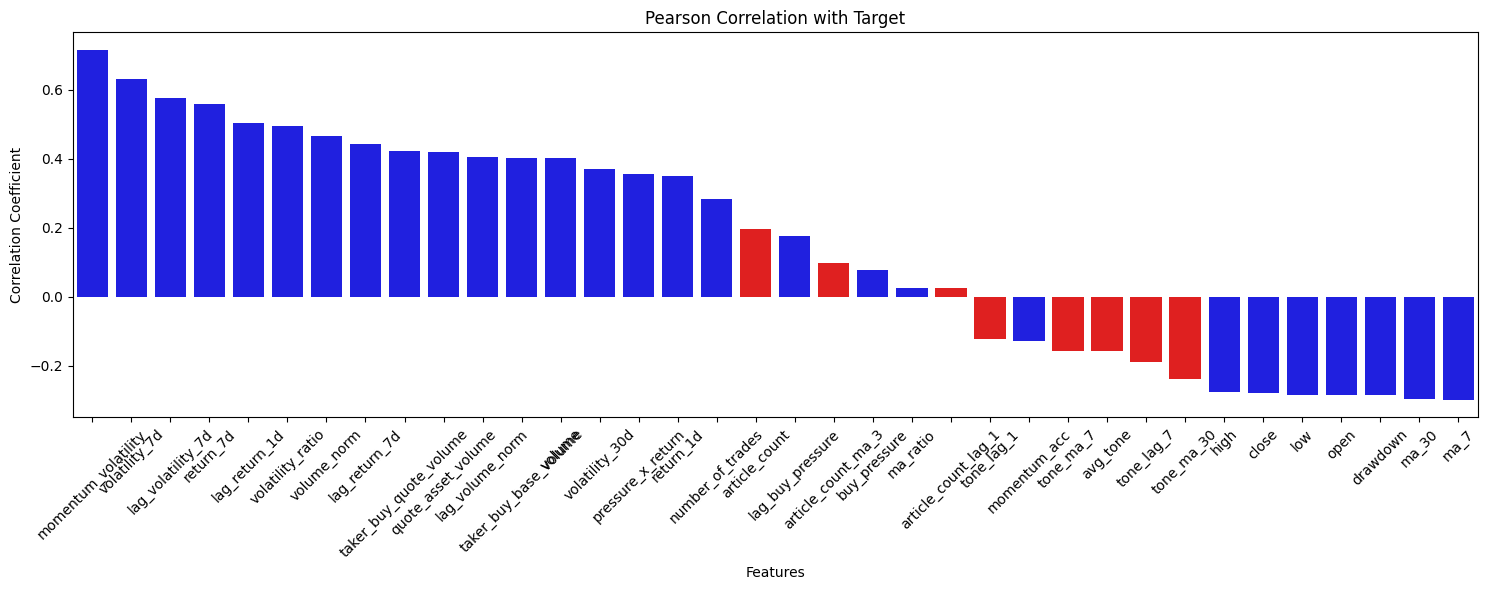

In [110]:
# Pearson correlation with target
corrs_pearson = (
    df_btc_media_and_price
    .corr(method="pearson")["target"]
    .sort_values(ascending=False)
    .drop("target")
)

media_cols = ["avg_tone", "article_count", "tone_ma_7", "tone_ma_30", "tone_lag_1", "tone_lag_7", "article_count_ma_3", "article_count_lag_1"]
colors = ["red" if col in media_cols else "blue" for col in corrs_pearson.index]

plt.figure(figsize=(15, 6))
sns.barplot(x=corrs_pearson.index, y=corrs_pearson.values, hue=corrs_pearson.index, palette=dict(zip(corrs_pearson.index, colors)), legend=False)
plt.xticks(rotation=45)
plt.title("Pearson Correlation with Target")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Features")
plt.tight_layout()
plt.show()


**Observations:**
- Market features dominate — **volatility features** (`volatility_ratio`, `momentum_volatility`, `volatility_7d`) are the strongest linear predictors in this bull-cycle window.
- Among media features, **`tone_lag_1`** stands out: yesterday's sentiment shows a notable linear correlation with crash probability, suggesting negative tone systematically precedes reversals.
- **`article_count` and all its derivatives show near-zero Pearson correlation** — media volume carries no linear predictive information on this dataset.
- Raw `avg_tone` and `tone_ma_7` show weak positive signal, confirming tone is directionally relevant but noisy.
- `return_1d` ranks surprisingly low — consistent with the 129-row bull-cycle window where short-term momentum is less predictive than volatility regime.

**Conclusion:**
Red bars (media features) cluster at the bottom of the ranking, except for `tone_lag_1` which stands out as the only media feature with meaningful linear signal. `article_count` derivatives contribute nothing linearly.


**Spearman Correlation with Target**


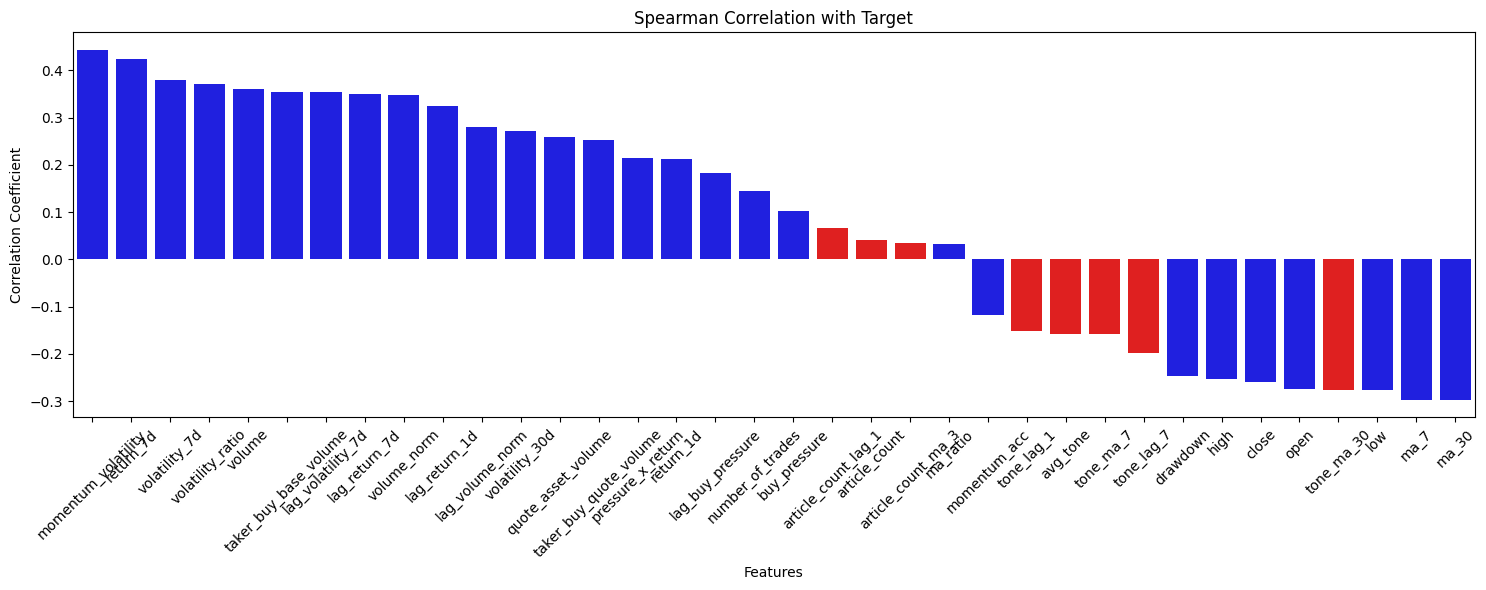

In [111]:
# Spearman correlation with target
corrs_spearman = df_btc_media_and_price.corr(method="spearman")["target"].sort_values(ascending=False).drop("target")
colors = ["red" if col in media_cols else "blue" for col in corrs_spearman.index]

plt.figure(figsize=(15, 6))
sns.barplot(x=corrs_spearman.index, y=corrs_spearman.values, hue=corrs_spearman.index, palette=dict(zip(corrs_spearman.index, colors)), legend=False)
plt.xticks(rotation=45)
plt.title("Spearman Correlation with Target")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Features")
plt.tight_layout()
plt.show()


**Observations:**
- Spearman ranking is consistent with Pearson: **volatility features dominate** the monotonic association with crash probability.
- **`tone_lag_1`** maintains its notable rank among media features — the monotonic relationship between prior-day negative sentiment and future crashes holds robustly.
- **`article_count`, `article_count_ma_3`, and `article_count_lag_1` remain near-zero** — Spearman's robustness to outliers does not rescue media volume features, confirming they carry no monotonic signal.
- `avg_tone` and `tone_ma_7` retain a weak but consistent positive rank.
- Spearman's robustness confirms that the flat signal from `article_count` is not driven by outliers — the feature is genuinely uninformative on this dataset.

**Conclusion:**
The monotonic analysis confirms the Pearson pattern: **tone dynamics (especially lagged)** are the only media features with real signal. Media volume adds nothing, even when measured monotonically.


**Mutual Information with Target**


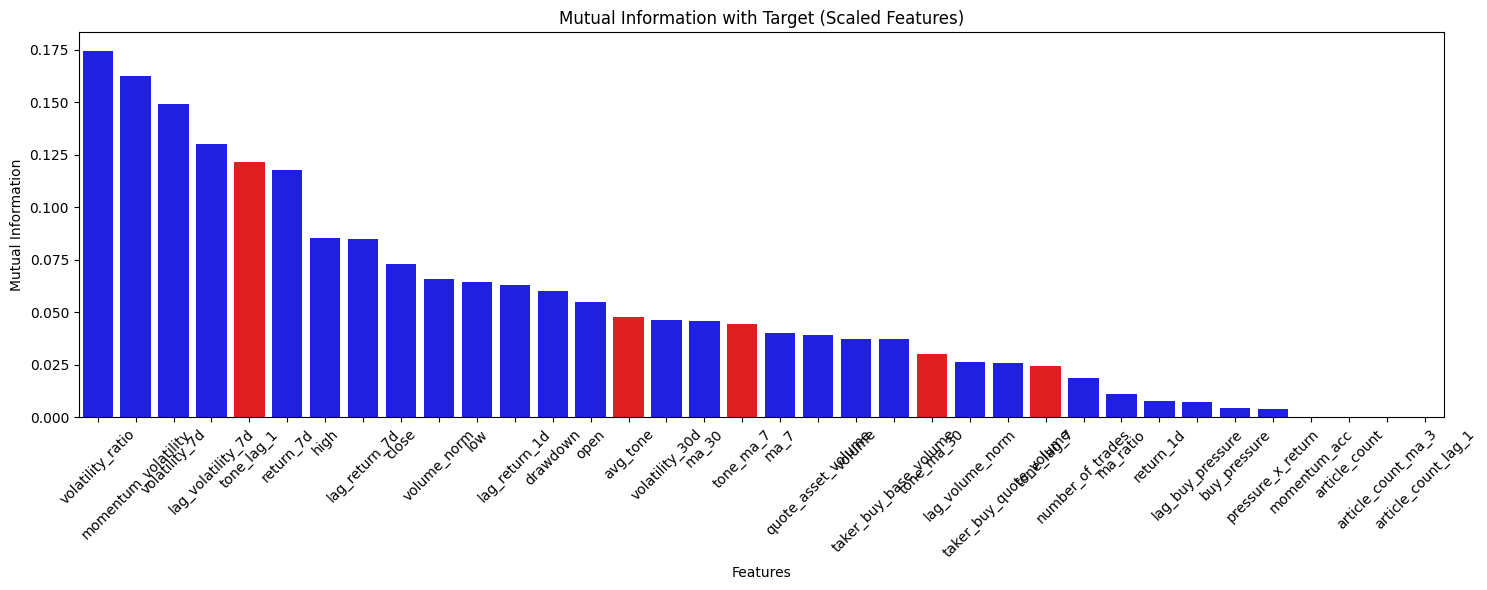

volatility_ratio          0.174676
momentum_volatility       0.162477
volatility_7d             0.149216
lag_volatility_7d         0.130278
tone_lag_1                0.121785
return_7d                 0.117630
high                      0.085656
lag_return_7d             0.084917
close                     0.073116
volume_norm               0.066108
low                       0.064446
lag_return_1d             0.063062
drawdown                  0.060200
open                      0.055104
avg_tone                  0.047766
volatility_30d            0.046458
ma_30                     0.046018
tone_ma_7                 0.044502
ma_7                      0.039984
quote_asset_volume        0.039407
volume                    0.037401
taker_buy_base_volume     0.037165
tone_ma_30                0.030339
lag_volume_norm           0.026206
taker_buy_quote_volume    0.026029
tone_lag_7                0.024287
number_of_trades          0.018738
ma_ratio                  0.011355
return_1d           

In [112]:
X = df_btc_media_and_price.drop(columns=["target"])
y = df_btc_media_and_price["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

mutual_info = mutual_info_classif(
    X_scaled,
    y,
    discrete_features=False,
    n_neighbors=5,
    random_state=42
)

mutual_info_series = pd.Series(mutual_info, index=X.columns).sort_values(ascending=False)
colors_mi = ["red" if col in media_cols else "blue" for col in mutual_info_series.index]

plt.figure(figsize=(15, 6))
sns.barplot(x=mutual_info_series.index, y=mutual_info_series.values, hue=mutual_info_series.index, palette=dict(zip(mutual_info_series.index, colors_mi)), legend=False)
plt.xticks(rotation=45)
plt.title("Mutual Information with Target (Scaled Features)")
plt.ylabel("Mutual Information")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

mutual_info_series

**Observations**

- Market features dominate the top of the MI ranking: `volatility_ratio` (0.175), `momentum_volatility` (0.162), `volatility_7d` (0.149), `lag_volatility_7d` (0.130).
- **`tone_lag_1` ranks 5th overall with MI = 0.122** — stronger than most market features including `return_7d` (0.118), `drawdown` (0.060), and `return_1d` (0.008). Yesterday's media tone is the **most informative feature in the dataset after volatility**.
- `avg_tone` (0.048) and `tone_ma_7` (0.045) add moderate non-linear information. Smoothing reduces the daily noise of raw tone.
- `tone_ma_30` (0.030) and `tone_lag_7` (0.024) contribute diminishing but non-zero signal.
- **`article_count`, `article_count_ma_3`, and `article_count_lag_1` all score MI = 0.000** — media volume provides absolutely **no non-linear information** on this dataset. This is a strong and unexpected result.
- `return_1d` (0.008) ranks near the bottom — in this 2023-2026 bull-cycle window, short-term momentum is nearly uninformative.

**Conclusion**

The MI analysis reveals a **clear and decisive split**:
- **Tone features** (especially `tone_lag_1`) add real non-linear predictive signal
- **Article count features** add zero information regardless of smoothing or lagging

This is the **inverse of the initial hypothesis** (media volume was expected to be the primary signal). The predictive value of media for BTC crash detection in 2023-2026 comes entirely from **sentiment dynamics**, not coverage volume.


**Combined Score — Media Feature Ranking**

To select media features in a principled and consistent way with notebooks 01 and 03, a **combined score** is computed for each media feature:

$$\text{score} = \frac{|\rho_{\text{Spearman}}|}{\max(|\rho_{\text{Spearman}}|)} + \frac{\text{MI}}{\max(\text{MI})}$$

- Each term is **normalized to [0, 1]** against the maximum across *all features* (not just media), so the scale reflects how a media feature compares to the strongest signal in the dataset.
- The combined score ranges from **0 to 2**: 2 means the feature is best-in-class on both metrics simultaneously.
- A feature scoring near **0 on both metrics** carries no information — linear, monotonic, or non-linear — and should be removed.

This approach is more robust than a raw MI threshold on a small 129-row dataset, as it cross-validates the non-linear signal (MI) with the monotonic signal (Spearman) before drawing conclusions.

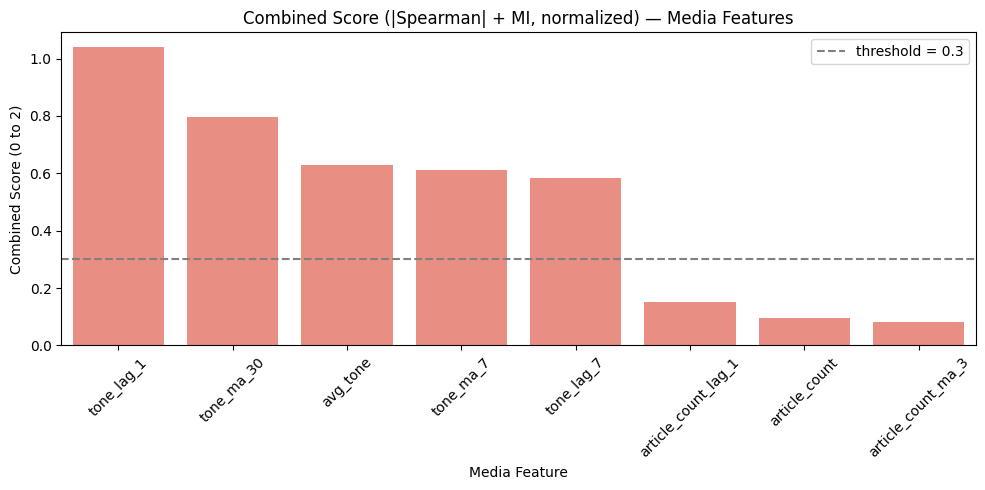

tone_lag_1             1.039309
tone_ma_30             0.796493
avg_tone               0.629593
tone_ma_7              0.610907
tone_lag_7             0.584655
article_count_lag_1    0.150877
article_count          0.094737
article_count_ma_3     0.080702
dtype: float64

In [113]:
media_score = (
    corrs_spearman.abs() / corrs_spearman.abs().max()
    + mutual_info_series / mutual_info_series.max()
)[media_cols].sort_values(ascending=False)

MEDIA_SCORE_THRESHOLD = 0.3

plt.figure(figsize=(10, 5))
sns.barplot(x=media_score.index, y=media_score.values, color="salmon")
plt.axhline(
    y=MEDIA_SCORE_THRESHOLD,
    color="gray", linestyle="--", linewidth=1.5,
    label=f"threshold = {MEDIA_SCORE_THRESHOLD}"
)
plt.xticks(rotation=45)
plt.title("Combined Score (|Spearman| + MI, normalized) — Media Features")
plt.ylabel("Combined Score (0 to 2)")
plt.xlabel("Media Feature")
plt.legend()
plt.tight_layout()
plt.show()

media_score

**Observations**

The combined scores reveal **two clearly separated groups**:

| Group | Features | Score range |
|---|---|---|
| ✅ Tone features | `tone_lag_1`, `tone_ma_30`, `avg_tone`, `tone_ma_7`, `tone_lag_7` | 0.585 – 1.039 |
| ❌ Article count | `article_count_lag_1`, `article_count`, `article_count_ma_3` | 0.081 – 0.151 |

- The **gap between 0.585 and 0.151** is very wide (~4×). This is the natural cut-off point, not an arbitrary choice.
- Article count features score > 0 **only because of a weak Spearman component** — their MI is 0.000. On a 129-row dataset, a weak Spearman correlation is likely spurious. A feature with zero MI but weak Spearman adds no non-linear information and should not be trusted.
- All 5 tone features have **consistent signal on both metrics** (Spearman and MI together), making them robust candidates despite the small sample.
- The threshold **0.3** sits at the midpoint of the gap — it is not sensitive to small shifts and correctly separates the two groups.

**Conclusion**

Features selected: `tone_lag_1`, `tone_ma_30`, `avg_tone`, `tone_ma_7`, `tone_lag_7` (score ≥ 0.3).  
Features dropped: `article_count`, `article_count_ma_3`, `article_count_lag_1` (score < 0.3, MI = 0).

### 5. Final Dataset for Modeling


In [114]:
df_btc_media_and_price = pd.merge(df_btc_price, df_btc_media, left_on="open_time", right_on="date", how="inner")
df_btc_media_and_price.drop(columns=["open_time", "date"], inplace=True)
print(f"Final dataset: {df_btc_media_and_price.shape[0]} rows, {df_btc_media_and_price.shape[1]} columns")
df_btc_media_and_price.columns

Final dataset: 129 rows, 37 columns


Index(['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume',
       'number_of_trades', 'taker_buy_base_volume', 'taker_buy_quote_volume',
       'return_1d', 'return_7d', 'volatility_7d', 'volatility_30d', 'drawdown',
       'volume_norm', 'buy_pressure', 'lag_return_1d', 'lag_return_7d',
       'lag_volatility_7d', 'lag_volume_norm', 'lag_buy_pressure',
       'momentum_acc', 'volatility_ratio', 'momentum_volatility',
       'pressure_x_return', 'ma_7', 'ma_30', 'ma_ratio', 'target', 'avg_tone',
       'article_count', 'tone_ma_7', 'tone_ma_30', 'tone_lag_1', 'tone_lag_7',
       'article_count_ma_3', 'article_count_lag_1'],
      dtype='str')

In [115]:
df_btc_media.columns

Index(['date', 'avg_tone', 'article_count', 'tone_ma_7', 'tone_ma_30',
       'tone_lag_1', 'tone_lag_7', 'article_count_ma_3',
       'article_count_lag_1'],
      dtype='str')

**Feature Selection**

**Market features** are taken directly from the selection established in notebook 01 (BTC EDA), validated on 3 115 rows with a correlation-based redundancy filter (threshold 0.9). Recomputing on 129 rows would produce unreliable estimates.

**Media features** are selected using the **combined score (|Spearman| + MI, normalized)** computed above, with a threshold of **0.3**:

| Feature | MI Score | Combined Score | Decision |
|---|---|---|---|
| `tone_lag_1` | 0.122 | 1.039 | ✅ Keep |
| `tone_ma_30` | 0.030 | 0.796 | ✅ Keep |
| `avg_tone` | 0.048 | 0.630 | ✅ Keep |
| `tone_ma_7` | 0.045 | 0.611 | ✅ Keep |
| `tone_lag_7` | 0.024 | 0.585 | ✅ Keep |
| `article_count_lag_1` | 0.000 | 0.151 | ❌ Drop — MI = 0, Spearman likely spurious |
| `article_count` | 0.000 | 0.095 | ❌ Drop — MI = 0 |
| `article_count_ma_3` | 0.000 | 0.081 | ❌ Drop — MI = 0 |

Threshold = **0.3** — chosen at the midpoint of the natural gap between the two groups (0.585 → 0.151). Features with MI = 0 and combined score < 0.3 are dropped regardless of their weak Spearman component, as the latter is unreliable on 129 rows.


In [116]:
SELECTED_FEATURES = [
    # Momentum
    "return_1d", "return_7d",

    # Volatility
    "volatility_7d", "volatility_30d",

    # Market behavior
    "buy_pressure",

    # Risk
    "drawdown",

    # Trend
    "ma_ratio",

    # Lags
    "lag_return_1d", "lag_return_7d",
    "lag_volatility_7d",
    "lag_buy_pressure",
    "lag_volume_norm",

    # Additional
    "momentum_acc",
    "momentum_volatility",
    "volume",
    "number_of_trades",
    "quote_asset_volume",

    # Media enrichment — tone (article_count derivatives dropped: MI = 0)
    "tone_lag_1",
    "avg_tone",
    "tone_ma_7",
    "tone_ma_30",
    "tone_lag_7",
]

TARGET = "target"

df_btc_media_and_price = df_btc_media_and_price[SELECTED_FEATURES + [TARGET]]
df_btc_media_and_price.head()


,return_1d,return_7d,volatility_7d,volatility_30d,buy_pressure,drawdown,ma_ratio,lag_return_1d,lag_return_7d,lag_volatility_7d,...,momentum_volatility,volume,number_of_trades,quote_asset_volume,tone_lag_1,avg_tone,tone_ma_7,tone_ma_30,tone_lag_7,target
0,0.003744,-0.047744,0.021040,0.027438,0.499829,-0.667827,0.990859,-0.000348,-0.035000,0.022706,...,-0.001005,154841.75786,4835978,3.473011e+09,-0.533521,-0.481394,-0.537987,-0.619152,-0.375572,0
1,-0.000902,-0.046062,0.021108,0.027431,0.501150,-0.668127,0.985493,0.003744,-0.047744,0.021040,...,-0.000972,203751.82957,6471278,4.569102e+09,-0.481394,-0.021060,-0.533938,-0.600656,-0.049405,0
2,-0.009462,-0.040776,0.020845,0.027315,0.497398,-0.671267,0.980710,-0.000902,-0.046062,0.021108,...,-0.000850,292519.80912,7813394,6.517595e+09,-0.021060,-1.067670,-0.644736,-0.608371,-0.292084,0
3,-0.022188,-0.081406,0.017758,0.027572,0.497604,-0.678561,0.970311,-0.009462,-0.040776,0.020845,...,-0.001446,301460.57272,8018963,6.641172e+09,-1.067670,-0.494609,-0.652728,-0.630323,-0.438668,0
4,-0.061884,-0.132242,0.025600,0.029363,0.491145,-0.698453,0.955088,-0.022188,-0.081406,0.017758,...,-0.003385,443658.28584,10076702,9.403029e+09,-0.494609,-1.259748,-0.670066,-0.682481,-1.138378,0


**Observations:**
- The final feature set has **22 features**: 17 market features + 5 tone media features + target.
- `article_count` and its two derivatives were **removed** — combined score ≈ 0 on both Spearman and MI.
- The 5 retained tone features span multiple time horizons: raw daily tone (`avg_tone`), 7-day and 30-day smoothing (`tone_ma_7`, `tone_ma_30`), and 1-day and 7-day lags (`tone_lag_1`, `tone_lag_7`).
- The inner join ensures **no NaN values** — the dataset is clean and ready for training.
- The training window (129 rows, 2023-2026) is small but covers a complete market cycle.

**Conclusion:**
The final dataset is ready for benchmarking. The hypothesis to test: does adding **5 tone features** (selected via combined Spearman + MI score) improve crash prediction compared to the market-only baseline from notebook 01?


### **General Conclusion — EDA BTC Price × Media**

#### **Key Findings**

- The media dataset covers **2023-03-05 to 2026-01-10** (129 days), corresponding to the post-FTX recovery, the 2024 halving cycle, and BTC's run to new all-time highs. This is a **small but market-relevant window**.

- The combined score analysis reveals a **decisive split** within media features:
  - **Tone features carry real predictive signal** — `tone_lag_1` (MI = 0.122, combined score = 1.039) ranks **5th overall** across all features. Yesterday's negative media sentiment is a strong non-linear predictor of crashes.
  - **Article count features are uninformative** — MI = 0.000 on all three, combined score < 0.2. Weak Spearman values are likely spurious on 129 rows.

- This is the **inverse of the initial hypothesis**: media volume was expected to spike around crash events, but tone dynamics (specifically the 1-day lag) proved to be the only informative media signal.

- Among **market features**, volatility dominates: `volatility_ratio` (0.175), `momentum_volatility` (0.162), `volatility_7d` (0.149) — consistent with the BTC EDA in notebook 01.

#### **Feature Selection Methodology**

| Feature type | Selection criterion |
|---|---|
| Market features | Correlation-based redundancy filter from notebook 01 (threshold 0.9) — validated on 3 115 rows |
| Media features | Combined score (|Spearman| + MI, normalized) > **0.3** — threshold set at the natural gap in the score distribution |

#### **Final Selected Features**

- **Momentum**
  - `return_1d`, `return_7d`

- **Volatility**
  - `volatility_7d`, `volatility_30d`

- **Market behavior**
  - `buy_pressure`

- **Risk context**
  - `drawdown`

- **Trend / regime**
  - `ma_ratio`

- **Temporal (lag features)**
  - `lag_return_1d`, `lag_return_7d`
  - `lag_volatility_7d`
  - `lag_buy_pressure`
  - `lag_volume_norm`

- **Additional market signals**
  - `momentum_acc`, `momentum_volatility`
  - `volume`, `number_of_trades`, `quote_asset_volume`

- **Media enrichment — tone only** *(article count dropped: combined score < 0.3, MI = 0)*
  - `tone_lag_1` *(combined score = 1.039, MI = 0.122 — strongest media signal)*
  - `tone_ma_30` *(combined score = 0.796)*
  - `avg_tone` *(combined score = 0.630)*
  - `tone_ma_7` *(combined score = 0.611)*
  - `tone_lag_7` *(combined score = 0.585)*

#### **Final Dataset Characteristics**

- **22 features** (17 market + 5 tone media)
- **129 rows** — 2023-03-05 to 2026-01-10
- **No missing values** (inner join ensures clean merge)
- **Small sample** — benchmark results require careful interpretation; cross-validation is essential

#### **Key Limitation**

The 129-row training window is significantly smaller than the full BTC price history (3 115 rows). This limits the statistical reliability of all estimates (MI, Spearman, combined score). Any performance gain observed in the benchmark should be validated with caution, and conclusions should not be assumed to generalize beyond the 2023-2026 market regime.

#### **Conclusion**

The dataset is **clean, structured, and ready for benchmarking**, with:
- A tone-based media enrichment grounded in a consistent dual-metric selection criterion (same methodology as notebooks 01 and 03)
- A clear hypothesis: do the 5 tone features improve crash prediction over the market-only baseline?
- A well-defined market window enabling direct comparison with the BTC-only benchmark (notebook 01)